<h1 style="color:green;font-size:22px;">Function 2 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;"">Introduction and illustrative analogy</h1>

**Function 2** is a two-dimensional black-box objective over the bounded domain $[0,1]^2$. Its analytical form and physical interpretation are unknown. The objective is to identify high-value input configurations under a limited sequential-query budget. The goal is to maximise **Function 2**.

The problem can be viewed as tuning two controls on an unknown system that returns a scalar score. Because the response surface is not observable directly, each new query must be selected using only the previously evaluated inputs and outputs.

To tackle this, Bayesian optimisation is used to balance broad exploration of the domain with local refinement of promising regions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;"">Week 1</h1>

**1.1 - Extraction of Initial Data**

In [2]:
inputs = np.load('Initial Data/function_2/initial_inputs.npy')
outputs = np.load('Initial Data/function_2/initial_outputs.npy')
print(inputs.shape, outputs.shape)

(10, 2) (10,)


In [3]:
data = pd.DataFrame(inputs, columns=['x1','x2'])
data['y'] = outputs
display(data)

,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**1.2 - Visual Data Exploration**

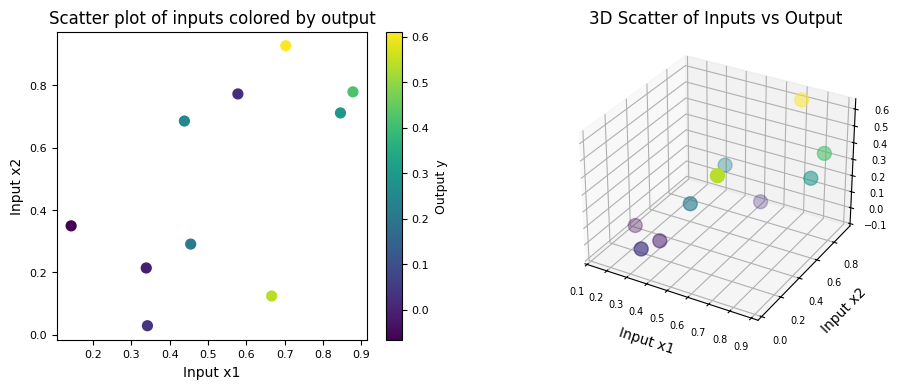

In [4]:
# Create figure with 2 subplots side by side
fig = plt.figure(figsize=(11,4))

# 2D-Data Exploration
ax1 = fig.add_subplot(1, 2, 1)
sc = ax1.scatter(data['x1'], data['x2'], c=data['y'], cmap='viridis', s=50)

cbar1 = plt.colorbar(sc, ax=ax1)
cbar1.set_label('Output y', fontsize=9)
cbar1.ax.tick_params(labelsize=8) 

ax1.tick_params(axis='both', labelsize=8)
ax1.set_xlabel('Input x1')
ax1.set_ylabel('Input x2')
ax1.set_title('Scatter plot of inputs colored by output')

# 3D-Data Exploration
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.scatter(data['x1'], data['x2'], data['y'], c=data['y'], cmap='viridis', s=100)
ax2.tick_params(axis='both', labelsize=7)
ax2.set_xlabel('Input x1')
ax2.set_ylabel('Input x2')
ax2.set_zlabel('Output y')
ax2.set_title('3D Scatter of Inputs vs Output')

plt.show()

**Observations:**
- \$ (x_1, x_2) \in [0, 1]^2\$, \$y \in  [-0.065624, 0.6112]\$  
- The highest initial value is 0.611205 at [0.702637, 0.926564].
- The second-highest initial value is 0.538996 at [0.665800, 0.123969].
- These two observations identify separated upper and lower candidate regions.
- Given the limited sample, the observations are insufficient to establish local maxima or infer the global geometry of Function 2.

**Visual Interpretation of the Initial Observations:**
The initial observations reveal two separated high-value regions:

- an upper region around [0.702637, 0.926564], with an observed value of 0.611205;
- a lower region around [0.665800, 0.123969], with an observed value of 0.538996.

These observations motivate further exploration around both areas. However, because the initial design contains only 10 points, the visual pattern should not be interpreted as evidence of a smooth gradient or confirmed local maxima.

**1.3 -  Bayesian Optimisation using Gaussian Process + Upper Confidence Bound**

Both EI and UCB combine the GP posterior mean with predictive uncertainty. UCB is used during the initial rounds because its exploration weight, controlled by κ, provides a transparent mechanism for prioritising uncertain regions while retaining sensitivity to high predicted values.

In [5]:
## Choice GP (Surrogate Model) + UCB (Acquisition Function)
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)

# Candidate points (grid)
x1 = np.linspace(0,1,50)
x2 = np.linspace(0,1,50)
xx1, xx2 = np.meshgrid(x1, x2)
X_grid = np.vstack([xx1.ravel(), xx2.ravel()]).T

y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound
kappa = 1.5
ucb = y_pred + kappa * sigma
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP +UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")


Next point (with GP +UCB):0.816327-1.000000


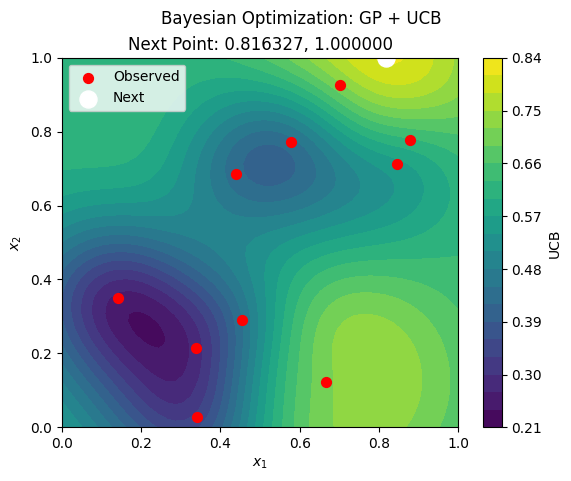

In [6]:
plt.subplot(1, 1, 1)
ct = plt.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
plt.colorbar(ct, label="UCB")
plt.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
plt.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')
plt.title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
    
plt.suptitle('Bayesian Optimization: GP + UCB')
plt.show()

**1.4 - Output ranges**

In [7]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

0.6112052157614438 0.6768288401987812


<h1 style="color:#0000CD;font-size:19px;"">Week 2</h1>

**2.1 - Previous Week's Query Result**

In [8]:
# New Query Point
x_new = np.array([0.816327, 1.000000])
y_new = -0.01280443954254286

def add_QueriedPoint(data, x_new, y_new):

    inputs = data[['x1', 'x2']].to_numpy()
    outputs = data['y'].to_numpy()
    
    # Checks if New Points is already included in data
    exists = False
    for i in range(inputs.shape[0]):
        if np.allclose(inputs[i], x_new) and np.isclose(outputs[i], y_new):
            exists = True
            break

    # Only adds if it doesn't exist already 
    if not exists:
        inputs = np.vstack([inputs, x_new])
        outputs = np.append(outputs, y_new)
        data = pd.DataFrame(inputs, columns=['x1', 'x2']).assign(y=outputs)
    
        print("Point added!")
    else:
        print("Point already exists, skipping addition.")
    return data

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**2.2 - Next Point Query**

In [9]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound
kappa = 1.5
ucb = y_pred + kappa * sigma
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP +UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP +UCB):0.755102-0.142857


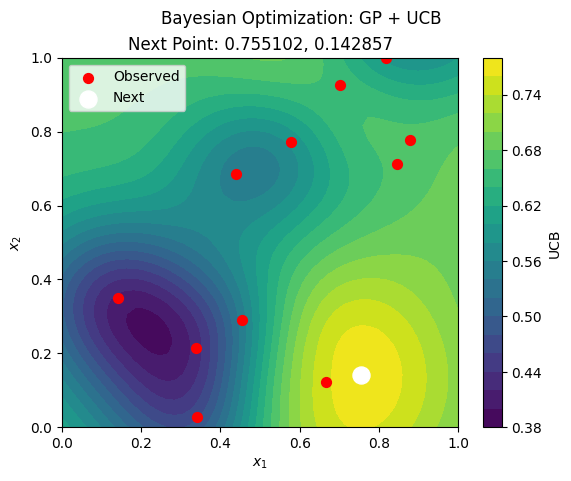

In [10]:
plt.subplot(1, 1, 1)
ct = plt.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
plt.colorbar(ct, label="UCB")
plt.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
plt.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')
plt.title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
    
plt.suptitle('Bayesian Optimization: GP + UCB')
plt.show()

**2.3 - Output ranges**

In [11]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

0.6112052157614438 0.6768288401987812


<h1 style="color:#0000CD;font-size:19px;"">Week 3</h1>

**3.1 - Previous Week's Query Result**

In [12]:
# New Query Point
x_new = np.array([0.755102, 0.142857])
y_new = 0.3310935219817136

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**3.2 - Next point query using UCB**

In [13]:
# GP Fit First
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound for exploration (optional, still using kappa)
kappa = 1.5
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]

# Continue exploration using UCB
print("Continue UCB exploration")
next_point = next_point_ucb
print(f"Next point (UCB): {next_point}")

Continue UCB exploration
Next point (UCB): [0.71428571 0.        ]


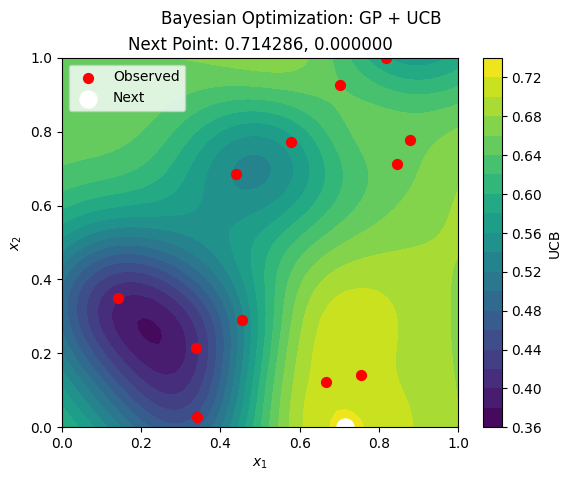

In [14]:
plt.subplot(1, 1, 1)
ct = plt.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
plt.colorbar(ct, label="UCB")
plt.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
plt.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')
plt.title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
    
plt.suptitle('Bayesian Optimization: GP + UCB')
plt.show()

**3.3 - Output ranges**

In [15]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

0.6112052157614438 0.6768288401987812


<h1 style="color:#0000CD;font-size:19px;"">Week 4</h1>

**4.1 - Previous Week's Query Result**

In [16]:
# New Query Point
x_new = np.array([0.714286, 0])
y_new = 0.6123942086993718

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**4.2 - Adaptive exploration** 
Following the improvement at the lower boundary, κ is temporarily increased from 1.5 to 2.25 to test whether the apparent high-value feature extends into a broader uncertain area.

In [17]:
# GP Fit First
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound for exploration (optional, still using kappa)
kappa = 2.25
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]

# Continue exploration using UCB
print("Continue UCB exploration")
next_point = next_point_ucb
print(f"Next point (UCB): {next_point}")

Continue UCB exploration
Next point (UCB): [0.83673469 0.        ]


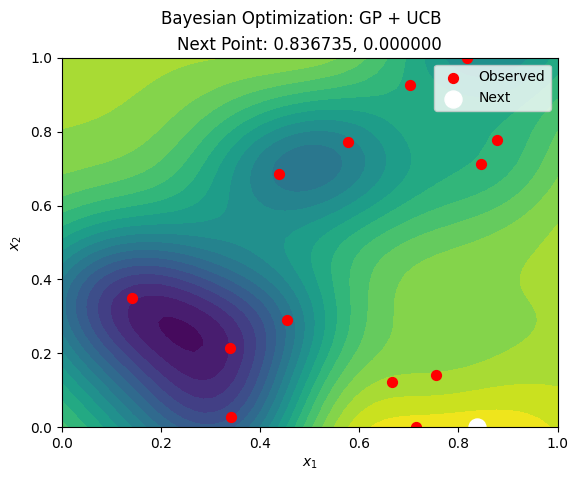

In [18]:
plt.subplot(1, 1, 1)
ct = plt.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
plt.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
plt.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')
plt.title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
    
plt.suptitle('Bayesian Optimization: GP + UCB')
plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 5</h1>

**5.1 - Previous Week's Query Result**

In [19]:
# New Query Point
x_new = np.array([0.836735, 0.000000])
y_new = 0.06218622316193309

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**5.2 - Exploratory RBF visualisation** 

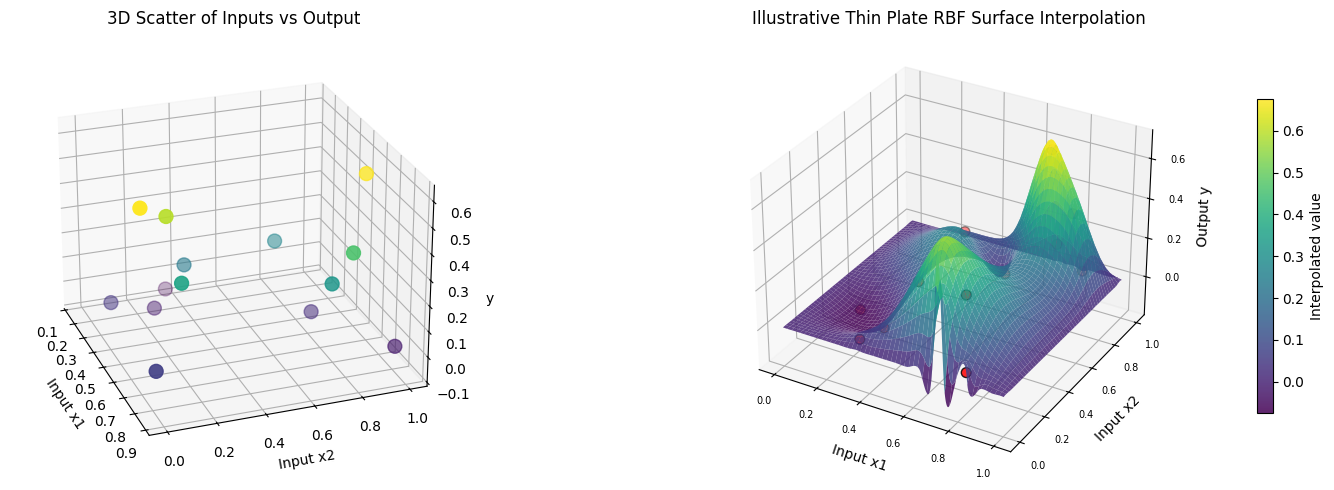

In [20]:
from scipy.interpolate import Rbf
from scipy.linalg import LinAlgWarning

warnings.filterwarnings("ignore", category=LinAlgWarning)

# Evaluated observations
x1 = data['x1']
x2 = data['x2']
y = data['y']

# Add synthetic boundary hugging points
n_edge = 20
t = np.linspace(0, 1, n_edge)

# four edges of the unit square
xb = np.concatenate([t, t, np.zeros_like(t), np.ones_like(t)])
yb = np.concatenate([np.zeros_like(t), np.ones_like(t), t, t])

# choose boundary values- slightly negative to create "hugging" along the edges
# Add synthetic negative boundary values to visually constrain the RBF surface.
# This reduces edge extrapolation and improves the contrast of promising interior regions. 
# These points are illustrative only and are not used in the optimisation model.
boundary_xy = np.unique(np.column_stack([xb, yb]),axis=0)
xb = boundary_xy[:, 0]
yb = boundary_xy[:, 1]
y_boundary = np.full(len(xb), -8e-4)

# combine original + boundary points
x1_aug = np.concatenate([x1, xb])
x2_aug = np.concatenate([x2, yb])
y_aug  = np.concatenate([y, y_boundary])

# exact interpolation on augmented dataset
rbf = Rbf(x1_aug, x2_aug, y_aug, function='thin_plate', smooth=0)

# grid
grid_n = 500
xg = np.linspace(0, 1, grid_n)
yg = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(xg, yg)
Z = rbf(X1, X2)

# plot 1
fig = plt.figure(figsize=(16, 5))
ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.scatter(data['x1'], data['x2'], data['y'], c=data['y'], cmap='viridis', s=100)

ax1.set_title('3D Scatter of Inputs vs Output')
ax1.set_xlabel("Input x1")
ax1.set_ylabel("Input x2")
ax1.set_zlabel("y")

ax1.view_init(elev=25, azim=-20)


# 3D-Data Exploration
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.set_title("Illustrative Thin Plate RBF Surface Interpolation")

surf = ax2.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.85, linewidth=0)
fig.colorbar(surf, ax=ax2, shrink=0.7, pad=0.10, label="Interpolated value")
ax2.scatter(x1, x2, y, c='red', s=50, edgecolor='k', label='Original points')
#ax.scatter(xb, yb, y_boundary, c='orange', s=25, label='Boundary control points')


ax2.tick_params(axis='both', labelsize=7)
ax2.set_xlabel('Input x1')
ax2.set_ylabel('Input x2')
ax2.set_zlabel('Output y')


plt.tight_layout()

plt.show()


A thin-plate radial basis function interpolation is used only to illustrate how the observed values might connect across the two-dimensional domain. Synthetic low-valued boundary control points are added to limit uncontrolled edge extrapolation. These control points are not observations and are not included in the Gaussian-process model or acquisition calculations.

The subsequent search regions are selected from the evaluated high-value observations, rather than from maxima implied by the interpolated surface:

- a lower-boundary region around [0.65, 0.75]x[0.00, 0.05]
- an upper region around [0.65, 0.75]x[0.85, 0.95]
  
The RBF plot should therefore be interpreted as an exploratory visualisation, not as an estimate of the true geometry of Function 2.

**5.3 - Next point query within observed high-value regions**

The poor result from the preceding exploratory query motivates a more exploitative search. A higher-resolution grid and κ=0.25 are therefore used within the two empirically promising regions only.

In [21]:
# Increase the resolution of Candidate points (grid)
x1 = np.linspace(0,1,500)
x2 = np.linspace(0,1,500)
xx1, xx2 = np.meshgrid(x1, x2)
X_grid = np.vstack([xx1.ravel(), xx2.ravel()]).T

kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Mask limiting area of search
mask = ((X_grid[:, 0] >= 0.65) & (X_grid[:, 0] <= 0.75) & (((X_grid[:, 1] >= 0.00) & (X_grid[:, 1] <= 0.05)) | (X_grid[:, 1] >= 0.85) & (X_grid[:, 1] <= 0.95)))

# Upper Confidence Bound
kappa = 0.25
ucb = y_pred + kappa * sigma

index_max = np.argmax(ucb[mask])
candidate_points = X_grid[mask]

next_point_ucb = np.array(candidate_points[index_max], float)
#next_point = np.array(X_grid[index_max], float)

print(f"Next point (with GP +UCB):{next_point_ucb[0]:.6f}-{next_point_ucb[1]:.6f}")

Next point (with GP +UCB):0.651303-0.048096


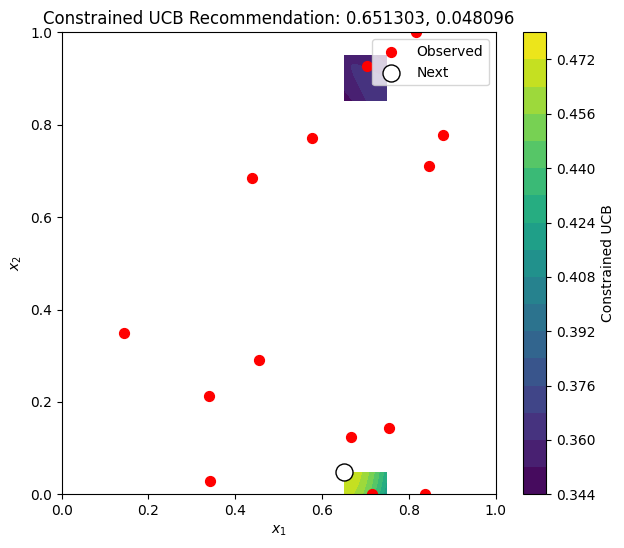

In [22]:
# Display only the acquisition values inside the permitted search regions
ucb_display = np.full_like(ucb, np.nan)
ucb_display[mask] = ucb[mask]

plt.figure(figsize=(7, 6))

ct = plt.contourf(
    xx1,
    xx2,
    ucb_display.reshape(xx1.shape),
    levels=20,
    cmap="viridis"
)

plt.colorbar(ct, label="Constrained UCB")
plt.scatter(
    inputs[:, 0],
    inputs[:, 1],
    c="red",
    s=50,
    label="Observed"
)
plt.scatter(
    next_point_ucb[0],
    next_point_ucb[1],
    c="white",
    s=150,
    edgecolor="black",
    label="Next"
)

plt.title(
    f"Constrained UCB Recommendation: "
    f"{next_point_ucb[0]:.6f}, {next_point_ucb[1]:.6f}"
)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 6</h1>

**6.1 - Previous Week's Query Result**

In [23]:
# New Query Point
x_new = np.array([0.651303, 0.048096])
y_new = 0.377662019816528

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**6.2 - Next point query switch using EI**

After several UCB rounds, Expected Improvement is used to target points offering positive expected improvement over the incumbent while retaining a contribution from predictive uncertainty. After the constrained UCB query, the optimisation returns to a full-domain search using Expected Improvement.

In [24]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Best observed value so far
f_best = np.max(outputs)

# Expected Improvement
improvement = y_pred - f_best

# Z value
Z = improvement / sigma

# Expected Improvement
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

# Next point
index_max = np.argmax(ei)
next_point_ei = X_grid[index_max]
print(f"Next point (with GP + EI): {next_point_ei[0]:.6f}-{next_point_ei[1]:.6f}")

Next point (with GP + EI): 0.629259-0.000000


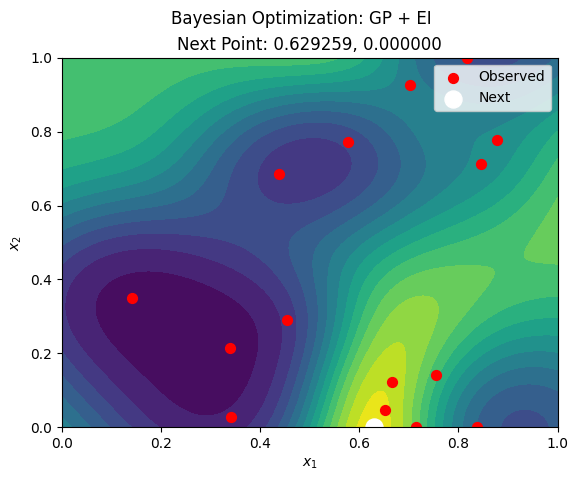

In [25]:
plt.subplot(1, 1, 1)
plt.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
plt.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
plt.scatter(next_point_ei[0], next_point_ei[1], c='white', s=150, label='Next')
plt.title(f'Next Point: {next_point_ei[0]:.6f}, {next_point_ei[1]:.6f}')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
    
plt.suptitle('Bayesian Optimization: GP + EI')
plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 7</h1>

**7.1 - Previous Week's Query Result**

In [26]:
# New Query Point
x_new = np.array([0.629259, 0.000000])
y_new = 0.2653569215665049

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**7.2 - Next point query using EI**

In [27]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Best observed value so far
f_best = np.max(outputs)

# Expected Improvement
improvement = y_pred - f_best

# Z value
Z = improvement / sigma

# Expected Improvement
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

# Next point
index_max = np.argmax(ei)
next_point_ei = X_grid[index_max]
print(f"Next point (with GP + EI): {next_point_ei[0]:.6f}-{next_point_ei[1]:.6f}")

Next point (with GP + EI): 0.697395-0.254509


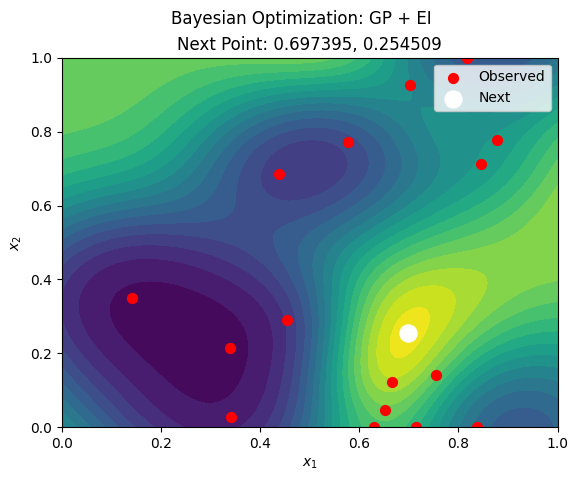

In [28]:
plt.subplot(1, 1, 1)
plt.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
plt.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
plt.scatter(next_point_ei[0], next_point_ei[1], c='white', s=150, label='Next')
plt.title(f'Next Point: {next_point_ei[0]:.6f}, {next_point_ei[1]:.6f}')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
    
plt.suptitle('Bayesian Optimization: GP + EI')
plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 8</h1>

**8.1 - Previous Week's Query Result**

In [29]:
# New Query Point
x_new = np.array([0.697395, 0.254509])
y_new = 0.5793919742652871

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**8.2 - Next point query using EI**

In [30]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Best observed value so far
f_best = np.max(outputs)

# Expected Improvement
improvement = y_pred - f_best

# Z value
Z = improvement / sigma

# Expected Improvement
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

# Next point
index_max = np.argmax(ei)
next_point_ei = X_grid[index_max]
print(f"Next point (with GP + EI): {next_point_ei[0]:.6f}-{next_point_ei[1]:.6f}")

Next point (with GP + EI): 0.711423-0.296593


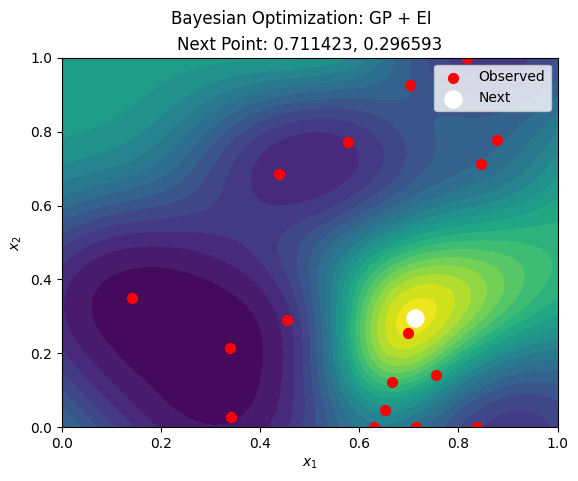

In [31]:
plt.subplot(1, 1, 1)
plt.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
plt.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
plt.scatter(next_point_ei[0], next_point_ei[1], c='white', s=150, label='Next')
plt.title(f'Next Point: {next_point_ei[0]:.6f}, {next_point_ei[1]:.6f}')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
    
plt.suptitle('Bayesian Optimization: GP + EI')
plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 9</h1>

**9.1 - Previous Week's Query Result**

In [32]:
# New Query Point
x_new = np.array([0.711423, 0.296593])
y_new = 0.5011802505017663

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**9.2 - Next Point: Manually Selected Local Refinement**

The two most recent full-domain EI queries did not improve the incumbent. The best lower-region observation remains [0.714286,0.000000]→0.612394, while nearby observations are materially lower. This suggests strong local sensitivity, although the precise peak geometry remains unknown.

The next query, [0.714286,0.025000], is therefore a targeted inward perturbation designed to test whether the response improves slightly inside the boundary.

In [33]:
next_point_manual = [0.714286,0.025000]
best_point = inputs[np.argmax(outputs)]
print(f"Best point: {best_point[0]:.6f}-{best_point[1]:.6f}")
print(f"Next point (Manually Selected): {next_point_manual[0]:.6f}-{next_point_manual[1]:.6f}")

Best point: 0.714286-0.000000
Next point (Manually Selected): 0.714286-0.025000


In [34]:
def plot_local_refinement(
    data,
    incumbent,
    candidate,
    title,
    candidate_label="Proposed manual refinement",
    xlim=(0.60, 0.86),
    ylim=(0.00, 0.32)
):
    local_data = data[
        data["x1"].between(*xlim)
        & data["x2"].between(*ylim)
    ]

    plt.figure(figsize=(9, 6))

    scatter = plt.scatter(
        local_data["x1"],
        local_data["x2"],
        c=local_data["y"],
        label="Observed evaluations",
        cmap="viridis",
        s=110,
        edgecolor="black"
    )

    for _, row in local_data.iterrows():
        plt.annotate(
            f'{row["y"]:.3f}',
            (row["x1"], row["x2"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    plt.scatter(
        incumbent[0],
        incumbent[1],
        marker="*",
        s=280,
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        label="Current incumbent"
    )

    plt.scatter(
        candidate[0],
        candidate[1],
        marker="X",
        s=180,
        facecolor="none",
        edgecolor="red",
        linewidth=2,
        label=candidate_label
    )

    plt.annotate(
        "",
        xy=candidate,
        xytext=incumbent,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.8,
            color="red"
        )
    )

    plt.colorbar(scatter, label="Observed objective value")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

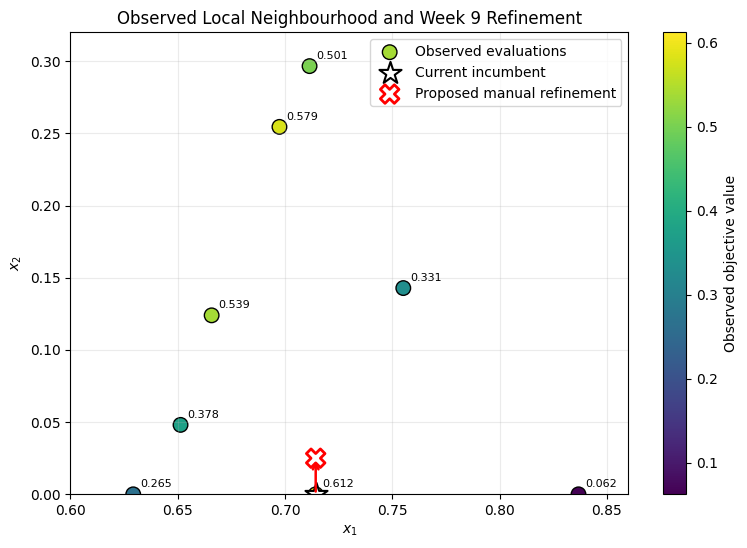

In [35]:
plot_local_refinement(
    data=data,
    incumbent=np.array(best_point),
    candidate=np.array(next_point_manual),
    title="Observed Local Neighbourhood and Week 9 Refinement"
)

<h1 style="color:#0000CD;font-size:19px;"">Week 10</h1>

**10.1 - Previous Week's Query Result**

In [36]:
# New Query Point
x_new = np.array([0.714286, 0.025000])
y_new = 0.632404083769128

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**10.2 - Next Point: Manually Selected Local Refinement**

The inward perturbation improved the incumbent from 0.612394 to 0.632404. The next point, [0.701786,0.037500], is a diagonal sensitivity probe: x1 is reduced by 0.0125 while x2 is increased by 0.0125. This tests whether the high-value region extends towards lower x1 and slightly higher x2.


In [37]:
next_point_manual = [0.701786, 0.0375]
x_best = inputs[np.argmax(outputs)]
print(f"Best point: {x_best[0]:.6f}-{x_best[1]:.6f}")
print(f"Next point (Manually Selected): {next_point_manual[0]:.6f}-{next_point_manual[1]:.6f}")

Best point: 0.714286-0.025000
Next point (Manually Selected): 0.701786-0.037500


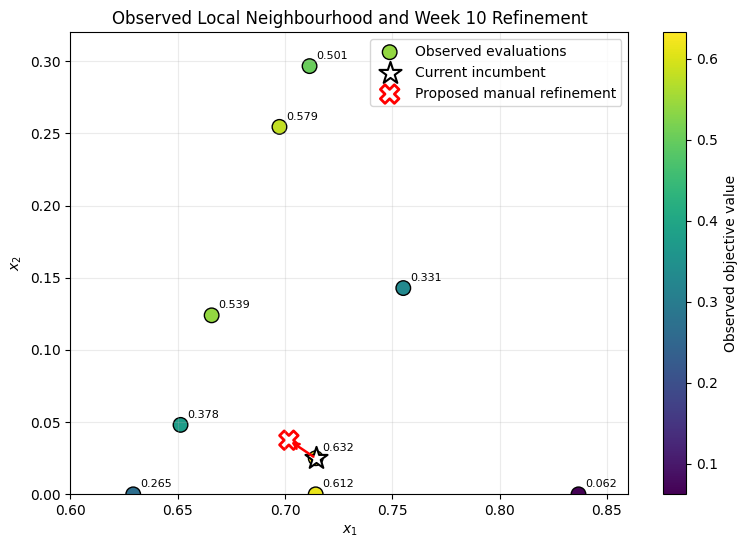

In [38]:
plot_local_refinement(
    data=data,
    incumbent=np.array(x_best),
    candidate=np.array(next_point_manual),
    title="Observed Local Neighbourhood and Week 10 Refinement"
)

<h1 style="color:#0000CD;font-size:19px;"">Week 11</h1>

**11.1 - Previous Week's Query Result**

In [39]:
# New Query Point
x_new = np.array([0.701786, 0.037500])
y_new = 0.5154473448445526

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**11.2 - Switch to PI**

The preceding diagonal probe at a lower x1 value returned a materially weaker result. The next search is therefore restricted to x
1 values at or above the incumbent, while x2 is allowed to vary locally around it.

A Matérn 5/2 kernel is introduced for the local phase to permit less rigid smoothness than the earlier RBF specification. Probability of Improvement with ξ=0 is used as an exploitative acquisition rule. Previously evaluated points within a Euclidean distance of 0.005 are excluded from selection.

During the local phase, the Matérn length scales and WhiteKernel level are re-estimated using the complete observation set. The local restriction applies to the candidate grid, not to the GP training data.


In [40]:
# Best observed point
best_idx = np.argmax(outputs)
x_best = inputs[best_idx]
y_best = outputs[best_idx]

print("Current best point:", x_best)
print("Current best y:", y_best)

# GP with Matérn 5/2 kernel
kernel = ConstantKernel(1.0) * Matern(
    length_scale=[0.02, 0.02],
    nu=2.5
) + WhiteKernel(noise_level=1e-10)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-12,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp.fit(inputs, outputs)

# Tight local grid around current best
x1_grid = np.linspace(
    max(0, x_best[0] - 0),
    min(1, x_best[0] + 0.2),
    1000
)

x2_grid = np.linspace(
    max(0, x_best[1] - 0.10),
    min(1, x_best[1] + 0.10),
    1000
)

xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([xx1.ravel(), xx2.ravel()])

# GP prediction
mu, sigma = gp.predict(X_grid, return_std=True)
sigma = np.maximum(sigma, 1e-12)

# Probability of Improvement, exploitative
xi = 0
Z = (mu - y_best - xi) / sigma
pi = norm.cdf(Z)

# Remove points too close to previous observations
for x_obs in inputs:
    pi[np.linalg.norm(X_grid - x_obs, axis=1) < 0.005] = -np.inf

# Select only one next point
idx = np.argmax(pi)
next_point = X_grid[idx]

print("\nSuggested next point:")
print(f"[{next_point[0]:.6f}, {next_point[1]:.6f}]")


Current best point: [0.714286 0.025   ]
Current best y: 0.632404083769128

Suggested next point:
[0.714286, 0.125000]


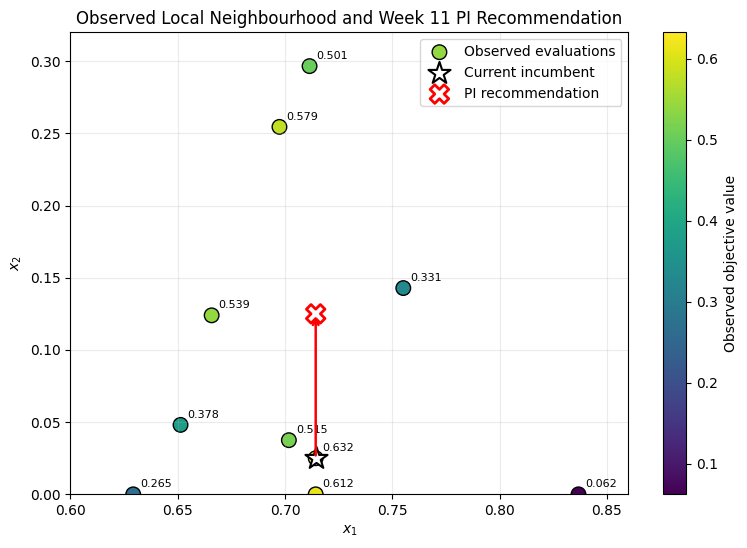

In [41]:
plot_local_refinement(
    data=data,
    incumbent=np.array(x_best),
    candidate=np.round(next_point,6),
    candidate_label="PI recommendation",
    title="Observed Local Neighbourhood and Week 11 PI Recommendation"
)

<h1 style="color:#0000CD;font-size:19px;"">Week 12</h1>

**12.1 - Previous Week's Query Result**

In [42]:
# New Query Point
x_new = np.array([0.714286, 0.125000])
y_new = 0.6138326854893379

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**12.2 - PI**

Following the strong result at [0.714286,0.125000], the x1 search window is reopened symmetrically around the incumbent to test whether nearby lower-x1 configurations offer a higher probability of improvement.

In [43]:
# Best observed point
best_idx = np.argmax(outputs)
x_best = inputs[best_idx]
y_best = outputs[best_idx]

print("Current best point:", x_best)
print("Current best y:", y_best)

# GP with Matérn 5/2 kernel
kernel = ConstantKernel(1.0) * Matern(
    length_scale=[0.02, 0.02],
    nu=2.5
) + WhiteKernel(noise_level=1e-10)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-12,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp.fit(inputs, outputs)

# Tight local grid around current best
x1_grid = np.linspace(max(0, x_best[0] - 0.1), min(1, x_best[0] + 0.1), 1000)
x2_grid = np.linspace(max(0, x_best[1] - 0.10), min(1, x_best[1] + 0.10), 1000)

xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([xx1.ravel(), xx2.ravel()])

# GP prediction
mu, sigma = gp.predict(X_grid, return_std=True)
sigma = np.maximum(sigma, 1e-12)

# Probability of Improvement, exploitative
xi = 0
Z = (mu - y_best - xi) / sigma
pi = norm.cdf(Z)

# Remove points too close to previous observations
for x_obs in inputs:
    pi[np.linalg.norm(X_grid - x_obs, axis=1) < 0.005] = -np.inf

# Select only one next point
idx = np.argmax(pi)
next_point = X_grid[idx]

print("\nSuggested next point:")
print(f"[{next_point[0]:.6f}, {next_point[1]:.6f}]")


Current best point: [0.714286 0.025   ]
Current best y: 0.632404083769128

Suggested next point:
[0.704576, 0.000000]


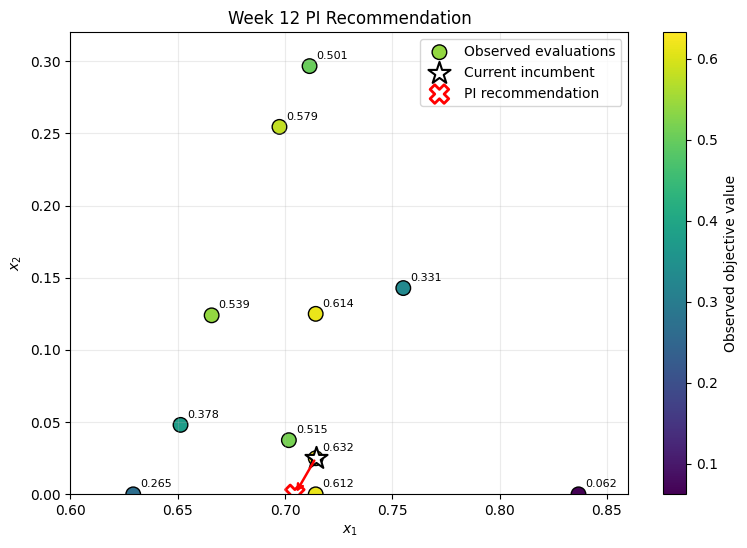

In [44]:
plot_local_refinement(
    data=data,
    incumbent=np.array(x_best),
    candidate=np.array(next_point),
    candidate_label="PI recommendation",
    title="Week 12 PI Recommendation"
)

<h1 style="color:#0000CD;font-size:19px;"">Week 13</h1>

**13.1 - Previous Week's Query Result**

In [45]:
# New Query Point
x_new = np.array([0.704576, 0.000])
y_new = 0.49814353895185043

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**13.2 - Observation**

At fixed x1=0.714286, the incumbent at x2=0.025000 remains the highest evaluated point. The observations at x2=0.000000 and x2=0.125000 are lower but remain comparatively strong.

The final point, [0.714286,0.062500], is therefore treated as an additional vertical-slice sensitivity probe within the interval [0,0.125]. It is not a claim that the optimum lies away from the current incumbent.


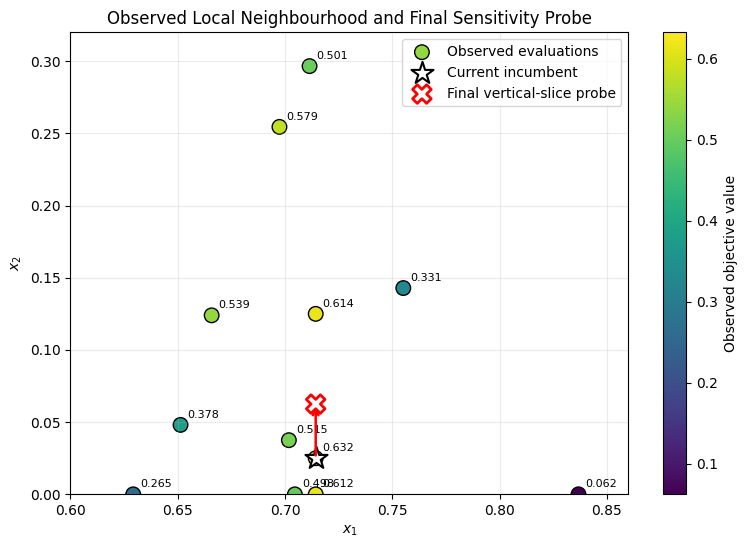

In [46]:
x_best = inputs[np.argmax(outputs)]
candidate_week_13 = np.array([0.714286, 0.062500])

plot_local_refinement(
    data=data,
    incumbent=np.array(x_best),
    candidate=candidate_week_13,
    candidate_label="Final vertical-slice probe",
    title="Observed Local Neighbourhood and Final Sensitivity Probe")

<h1 style="color:#0000CD;font-size:19px;"">Final Results</h1>

In [47]:
# Queried Point result
x_new = np.array([0.714286, 0.062500])
y_new = 0.543542952731858

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


- The best initial observation was y=0.611205 at [0.702637,0.926564].
- The sequential optimisation improved the incumbent to y=0.632404 at [0.714286,0.025000], representing an absolute improvement of 0.021199, or approximately 3.47%.
- The final query at [0.714286,0.062500] returned 0.543543 and did not improve the incumbent.

Overall, the results indicate a narrow high-value region around x1 ~0.714, with material sensitivity to relatively small changes in both coordinates. The best evaluated configuration lies in the lower-x2 region, where the surrounding probes also indicate substantial local sensitivity. These results describe the evaluated configurations and do not establish the global optimum.